# 1. Setup and Imports

Install required packages

In [2]:
!pip install selenium


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 499.2/499.2 kB 11.3 MB/s eta 0:00:00


Import all necessary libraries

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# 2. Scraping IMDb Top 250 Movies

2.1 Configure Selenium WebDriver

In [5]:
# Set up Selenium to handle JavaScript-loaded content
chrome_options = Options()
chrome_options.add_argument("--headless")
chrome_options.add_argument("--disable-gpu")
chrome_options.add_argument("--window-size=1920x1080")
chrome_options.add_argument("--disable-notifications")
chrome_options.add_argument("--no-sandbox")
chrome_options.add_argument("--disable-dev-shm-usage")
chrome_options.add_argument(
    f"user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36")

In [6]:
# Initialize the driver
driver = webdriver.Chrome(options=chrome_options)

2.2 Load IMDb Top 250 Page and Scroll

In [7]:
# Define the URL for IMDb top movies
url = 'https://www.imdb.com/chart/top/'

In [8]:
# Load the page with Selenium
print("Loading IMDb Top 250 page...")
driver.get(url)

Loading IMDb Top 250 page...


In [9]:
# Wait for the page to load completely and scroll to ensure all content is loaded
wait = WebDriverWait(driver, 10)
wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, 'li.ipc-metadata-list-summary-item')))

<selenium.webdriver.remote.webelement.WebElement (session="7d23ec5bd071d4a114523f2a22145ba7", element="f.3AFFD4E9D9CB51C4B2E010F1398B0AF0.d.C6D7762255A2D51D8EDD7B7F126939CB.e.45")>

In [10]:
# Scroll down to load all content
print("Scrolling to load all movies...")
last_height = driver.execute_script("return document.body.scrollHeight")
while True:
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(2)
    new_height = driver.execute_script("return document.body.scrollHeight")
    if new_height == last_height:
        break
    last_height = new_height

Scrolling to load all movies...


In [11]:
# Get the page source after JavaScript execution
page_source = driver.page_source
soup = BeautifulSoup(page_source, 'html.parser')

In [12]:
# Close the driver
driver.quit()

# 2.3 Extract Basic Movie Information

In [13]:
# Initialize lists to store movie data
titles = []
years = []
ratings = []
movie_urls = []

In [14]:
# Find all movie entries on the page
movie_containers = soup.select('li.ipc-metadata-list-summary-item')
print(f"Found {len(movie_containers)} movies on the page")

Found 250 movies on the page


In [15]:
# Extract basic information and URLs for detailed scraping
for container in movie_containers[:250]:
    # Extract title (removing the rank number at the beginning)
    title_element = container.select_one('h3.ipc-title__text')
    if title_element:
        title = re.sub(r'^\d+\.\s*', '', title_element.text.strip())
        titles.append(title)
    else:
        titles.append('N/A')

    # Extract movie URL for detailed information
    link_element = container.select_one('a.ipc-title-link-wrapper')
    if link_element and 'href' in link_element.attrs:
        movie_url = 'https://www.imdb.com' + link_element['href']
        movie_urls.append(movie_url)
    else:
        movie_urls.append('N/A')

    # Extract rating
    rating_element = container.select_one('span.ipc-rating-star--imdb')
    if rating_element:
        rating_text = rating_element.text.strip()
        rating_match = re.search(r'(\d+\.\d+)', rating_text)
        if rating_match:
            ratings.append(rating_match.group(1))
        else:
            ratings.append('N/A')
    else:
        ratings.append('N/A')

    # Try to extract year directly from the list item
    year_element = container.select_one('span.cli-title-metadata-item')
    if year_element and year_element.text.strip().isdigit():
        years.append(year_element.text.strip())
    else:
        years.append(None)

print(f"Extracted basic information for {len(titles)} movies")

Extracted basic information for 250 movies


# 3. Scrape Detailed Movie Information

3.1 Helper Function for Movie Details

In [16]:
def get_movie_details(url, existing_year=None):
    if url == 'N/A':
        return existing_year or 'N/A', ['N/A'], 'N/A'

    try:
        response = requests.get(url, headers={
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'})
        soup = BeautifulSoup(response.content, 'html.parser')

        # Extract year if not already available
        year = existing_year
        if not year:
            year_selectors = [
                'span.sc-8c396aa2-2',
                'a.ipc-link.ipc-link--baseAlt.ipc-link--inherit-color',
                'span.sc-52284603-2.iTRONr',
                'ul.ipc-inline-list.ipc-inline-list--show-dividers.sc-8c396aa2-0 li.ipc-inline-list__item'
            ]

            for selector in year_selectors:
                year_elements = soup.select(selector)
                for element in year_elements:
                    text = element.text.strip()
                    year_match = re.search(r'(\d{4})', text)
                    if year_match:
                        year = year_match.group(1)
                        break
                if year:
                    break

            if not year:
                page_text = soup.get_text()
                year_matches = re.findall(r'(\b(?:19|20)\d{2}\b)', page_text)
                if year_matches:
                    import datetime
                    current_year = datetime.datetime.now().year
                    for y in year_matches:
                        y_int = int(y)
                        if 1900 <= y_int <= current_year:
                            year = y
                            break

            if not year:
                year = 'N/A'

        # Extract genres
        genre_elements = soup.select('div.ipc-chip-list a.ipc-chip')
        genres = [genre.text.strip() for genre in genre_elements] if genre_elements else ['N/A']

        # Extract movie length
        length = 'N/A'
        runtime_elements = soup.select('li.ipc-inline-list__item')
        for element in runtime_elements:
            if 'h' in element.text and 'm' in element.text:
                length = element.text.strip()
                break

        return year, genres, length

    except Exception as e:
        print(f"Error scraping {url}: {e}")
        return existing_year or 'N/A', ['N/A'], 'N/A'

3.2 Scrape All Movies for Details

In [17]:
genres = []
updated_years = []
lengths = []

print("Starting to scrape detailed information for each movie...")
for i, url in enumerate(movie_urls):
    print(f"Scraping details for movie {i + 1}/{len(movie_urls)}: {titles[i]}")
    year, movie_genres, length = get_movie_details(url, years[i])
    updated_years.append(year)
    genres.append(movie_genres)
    lengths.append(length)

    # Add delay to avoid overloading the server
    time.sleep(1)

Starting to scrape detailed information for each movie...
Scraping details for movie 1/250: The Shawshank Redemption
Scraping details for movie 2/250: The Godfather
Scraping details for movie 3/250: The Dark Knight
Scraping details for movie 4/250: The Godfather Part II
Scraping details for movie 5/250: 12 Angry Men
Scraping details for movie 6/250: The Lord of the Rings: The Return of the King
Scraping details for movie 7/250: Schindler's List
Scraping details for movie 8/250: Pulp Fiction
Scraping details for movie 9/250: The Lord of the Rings: The Fellowship of the Ring
Scraping details for movie 10/250: The Good, the Bad and the Ugly
Scraping details for movie 11/250: Forrest Gump
Scraping details for movie 12/250: The Lord of the Rings: The Two Towers
Scraping details for movie 13/250: Fight Club
Scraping details for movie 14/250: Inception
Scraping details for movie 15/250: Star Wars: Episode V - The Empire Strikes Back
Scraping details for movie 16/250: The Matrix
Scraping detai

# 4. Create DataFrame and Save Data

In [18]:
movies_data = {
    'Title': titles,
    'Year': updated_years,
    'Length': lengths,
    'Rating': ratings,
    'Genres': genres,
    'URL': movie_urls
}

df = pd.DataFrame(movies_data)

# Convert Year to numeric, coercing errors to NaN
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Convert Rating to numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

print(f"Created DataFrame with {len(df)} movies")
print(df.head())

# Save to CSV
df.to_csv('imdb_top_250_movies_detailed.csv', index=False)
print("Data saved to imdb_top_250_movies_detailed.csv")

Created DataFrame with 250 movies
                      Title  Year  Length  Rating  \
0  The Shawshank Redemption  1994  2h 22m     9.3   
1             The Godfather  1972  2h 55m     9.2   
2           The Dark Knight  2008  2h 32m     9.0   
3     The Godfather Part II  1974  3h 22m     9.0   
4              12 Angry Men  1957  1h 36m     9.0   

                                              Genres  \
0          [Epic, Period Drama, Prison Drama, Drama]   
1            [Epic, Gangster, Tragedy, Crime, Drama]   
2  [Action Epic, Epic, Superhero, Tragedy, Action...   
3            [Epic, Gangster, Tragedy, Crime, Drama]   
4   [Legal Drama, Psychological Drama, Crime, Drama]   

                                                 URL  
0  https://www.imdb.com/title/tt0111161/?ref_=cht...  
1  https://www.imdb.com/title/tt0068646/?ref_=cht...  
2  https://www.imdb.com/title/tt0468569/?ref_=cht...  
3  https://www.imdb.com/title/tt0071562/?ref_=cht...  
4  https://www.imdb.com/title/tt005

# 5. Data Exploration and Visualization

5.1 Import Visualization Libraries

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

5.2 Basic Data Overview

In [20]:
print(f"Dataset shape: {df.shape}")
print("\nBasic statistics for numerical attributes:")
print(df[['Rating', 'Year']].describe())

Dataset shape: (250, 6)

Basic statistics for numerical attributes:
           Rating         Year
count  250.000000   250.000000
mean     8.310000  1988.288000
std      0.234606    25.581217
min      8.000000  1921.000000
25%      8.100000  1972.250000
50%      8.200000  1995.000000
75%      8.400000  2008.750000
max      9.300000  2025.000000


5.3 DataFrame Summary

In [21]:
df.describe()

,Year,Rating
count,250.000000,250.000000
mean,1988.288000,8.310000
std,25.581217,0.234606
min,1921.000000,8.000000
25%,1972.250000,8.100000
50%,1995.000000,8.200000
75%,2008.750000,8.400000
max,2025.000000,9.300000


5.4 Checking for Missing Values

In [22]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
Title     0
Year      0
Length    0
Rating    0
Genres    0
URL       0
dtype: int64


5.5 Converting the 'Year' Column to Numeric Type

In [23]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

5.6 Converting the 'Rating' Column to Numeric Type

In [24]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

5.7 Visualizing the Distribution of IMDb Ratings

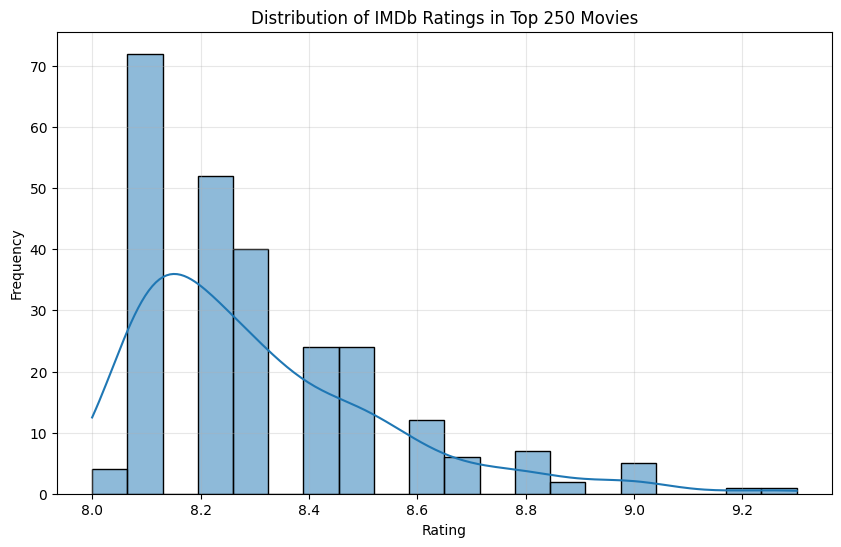

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], kde=True, bins=20)
plt.title('Distribution of IMDb Ratings in Top 250 Movies')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

5.8 Visualizing the Distribution of Movie Release Years

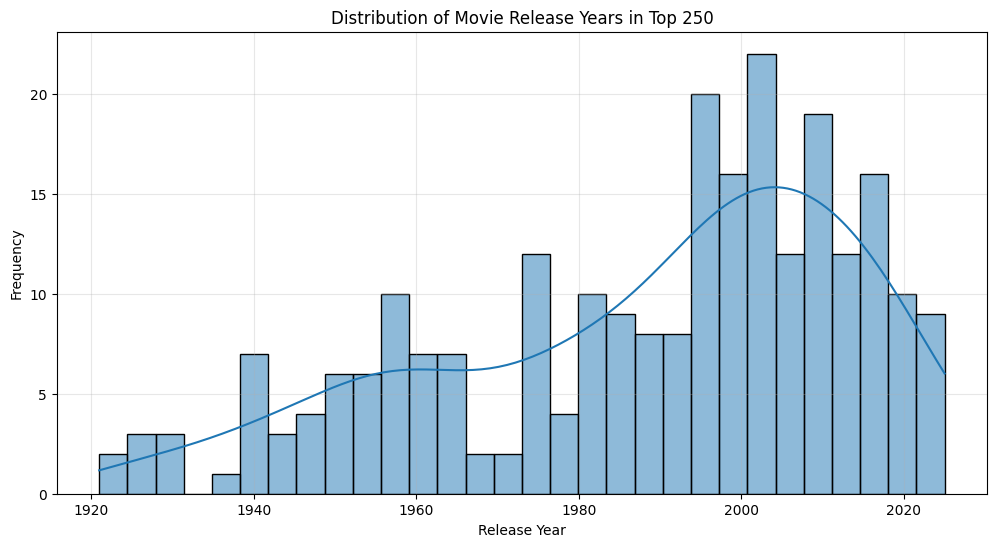

In [26]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Year'], kde=True, bins=30)
plt.title('Distribution of Movie Release Years in Top 250')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

5.9 Split the genres, handling potential float values

In [27]:
genres = [
    genre.strip()
    for sublist in df['Genres'].apply(lambda x: x if isinstance(x, list) else str(x).split(',')).tolist()
    for genre in sublist
    if genre.strip()
]

genre_counts = pd.Series(genres).value_counts()
genre_counts

,count
Drama,190
Adventure,57
Epic,56
Thriller,52
Crime,51
...,...
Kaiju,1
Steamy Romance,1
Vampire Horror,1
Shōnen,1


5.10.1 Extracting Hours and Minutes from the 'Length' Column

In [28]:
length_parts = df['Length'].str.extract(r'(\d+)h\s*(\d*)m').astype(float).fillna(0)

5.10.2 Visualizing the Distribution of Movie Lengths

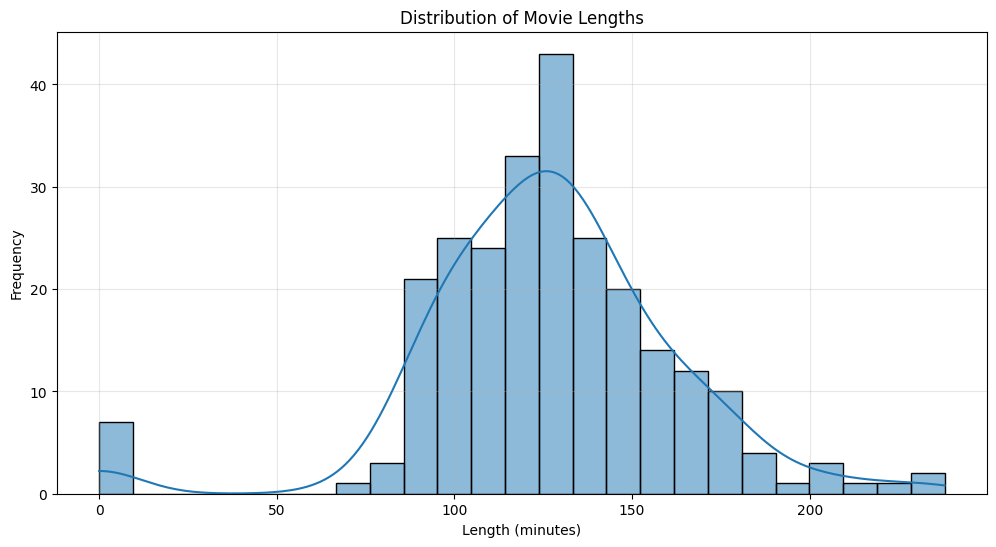

In [29]:
plt.figure(figsize=(12, 6))
df['Length_Minutes'] = length_parts[0] * 60 + length_parts[1]
sns.histplot(df['Length_Minutes'], kde=True, bins=25)
plt.title('Distribution of Movie Lengths')
plt.xlabel('Length (minutes)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

5.11 Visualizing the Distribution of Movie Ratings in IMDb Top 250

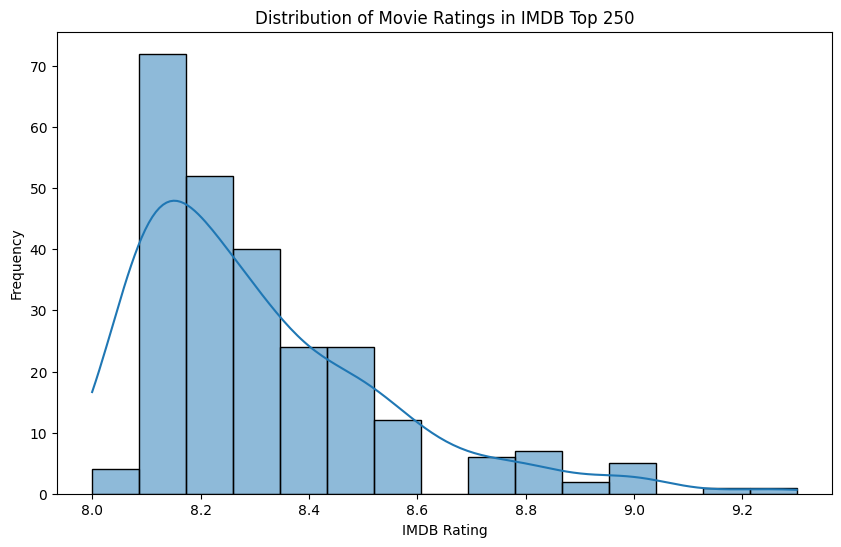

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=15, kde=True)
plt.title('Distribution of Movie Ratings in IMDB Top 250')
plt.xlabel('IMDB Rating')
plt.ylabel('Frequency')
plt.show()

5.12 Analyzing Genre Distribution in IMDb Top 250 Movies

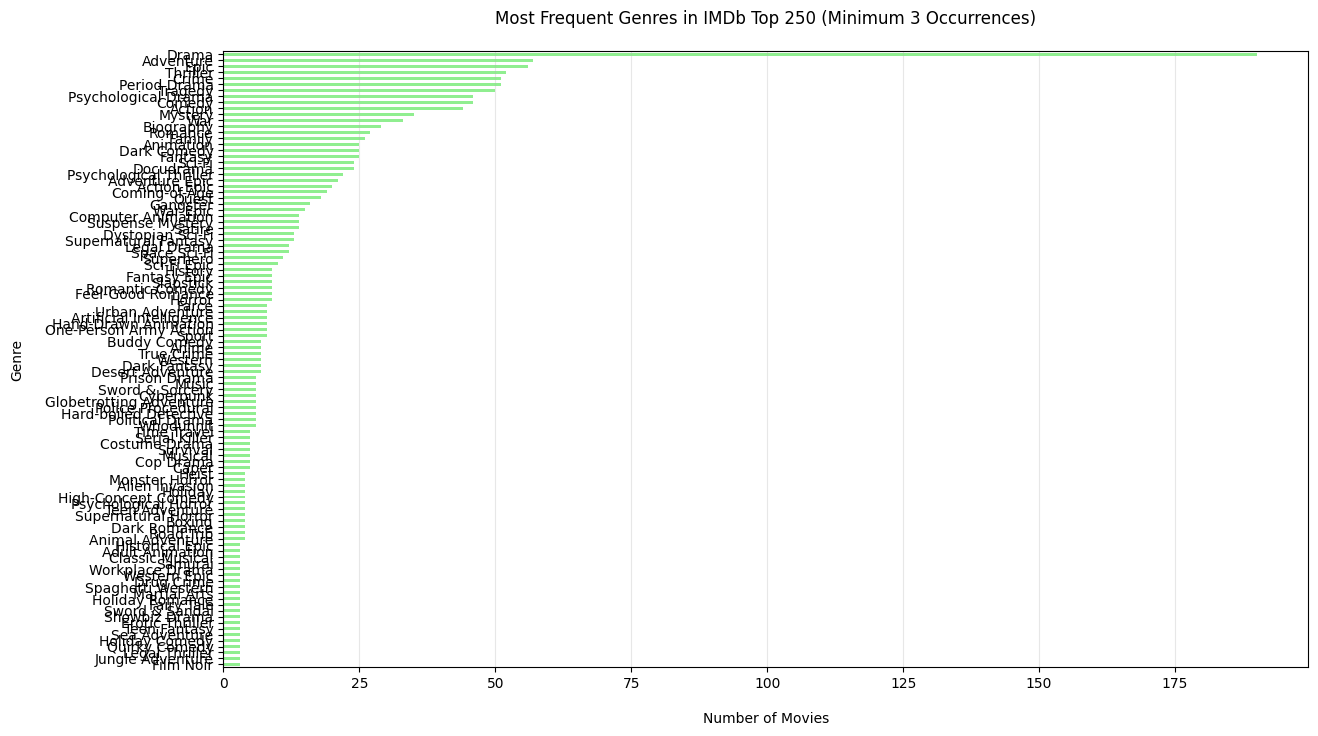

In [31]:
# Explode the list-based Genres column into individual rows
genres_series = df['Genres'].explode()

# Calculate genre frequencies and filter out rare genres
genre_counts = genres_series.value_counts()
common_genres = genre_counts[genre_counts >= 3]  # Filter genres with ≥3 occurrences

## Visualizing Common Genres
plt.figure(figsize=(14, 8))
common_genres.plot(kind='barh', color='lightgreen')
plt.title('Most Frequent Genres in IMDb Top 250 (Minimum 3 Occurrences)', pad=20)
plt.xlabel('Number of Movies', labelpad=15)
plt.ylabel('Genre', labelpad=15)
plt.gca().invert_yaxis()  # Display highest counts at top
plt.grid(axis='x', alpha=0.3)
plt.show()

5.13 Analyzing the Average IMDb Rating Trend by Decade

<ipython-input-32-01a538211b2a>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Decade', y='Rating', data=df,


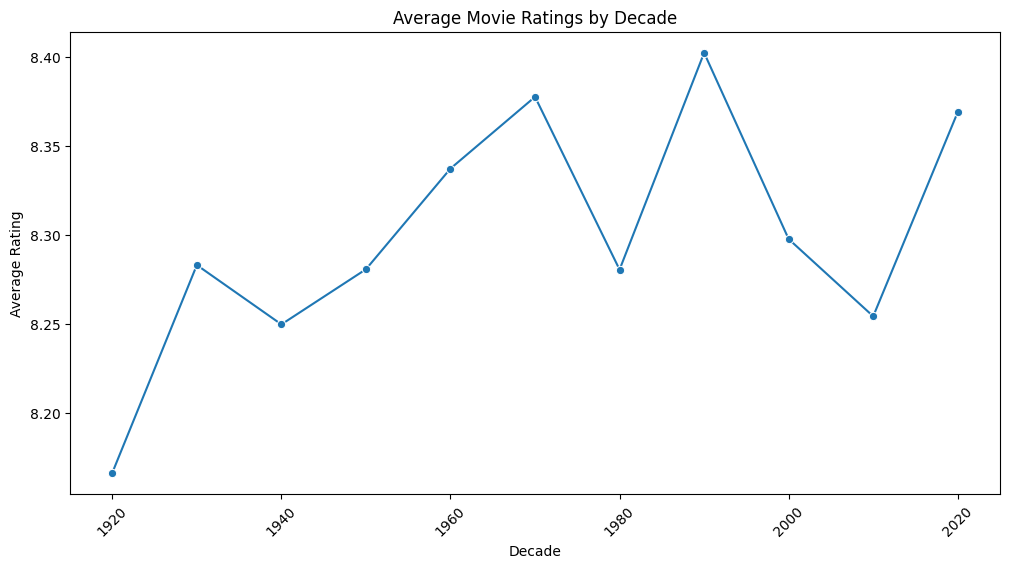

In [32]:
plt.figure(figsize=(12,6))
df['Decade'] = (df['Year'] // 10) * 10
sns.lineplot(x='Decade', y='Rating', data=df,
            estimator='mean', ci=None, marker='o')
plt.title('Average Movie Ratings by Decade')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

5.14 Analyzing Top Genre Combinations

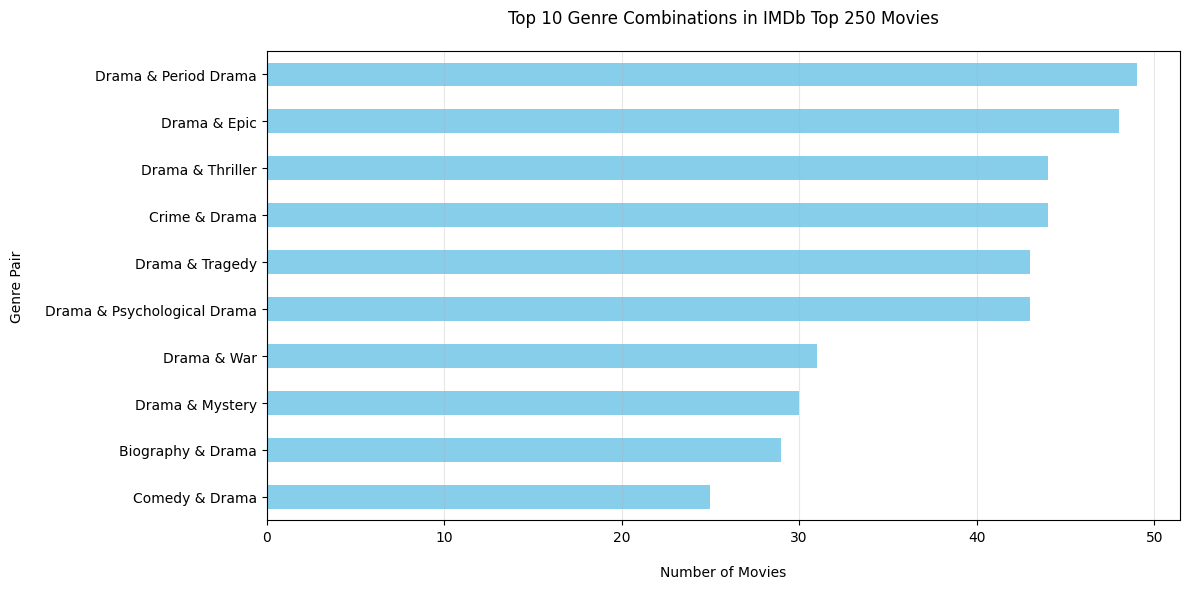

In [33]:
# Generate all possible 2-genre combinations for movies with ≥2 genres
from itertools import combinations
from collections import Counter

# Create sorted 2-genre tuples and count frequencies
genre_pairs = df['Genres'].apply(
    lambda x: [tuple(sorted(pair)) for pair in combinations(x, 2)] if len(x)>=2 else []
).explode()

top_combinations = genre_pairs.value_counts().head(10)

## Visualizing Frequent Genre Pairs
plt.figure(figsize=(12, 6))
ax = top_combinations.plot(kind='barh', color='skyblue')
plt.title('Top 10 Genre Combinations in IMDb Top 250 Movies', pad=20)
plt.xlabel('Number of Movies', labelpad=15)
plt.ylabel('Genre Pair', labelpad=15)
plt.gca().invert_yaxis()  # Show highest count at top

# Format genre pair labels
labels = [' & '.join(pair) for pair in top_combinations.index]
ax.set_yticklabels(labels)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

5.15 Visualizing the Average IMDb Rating by Year

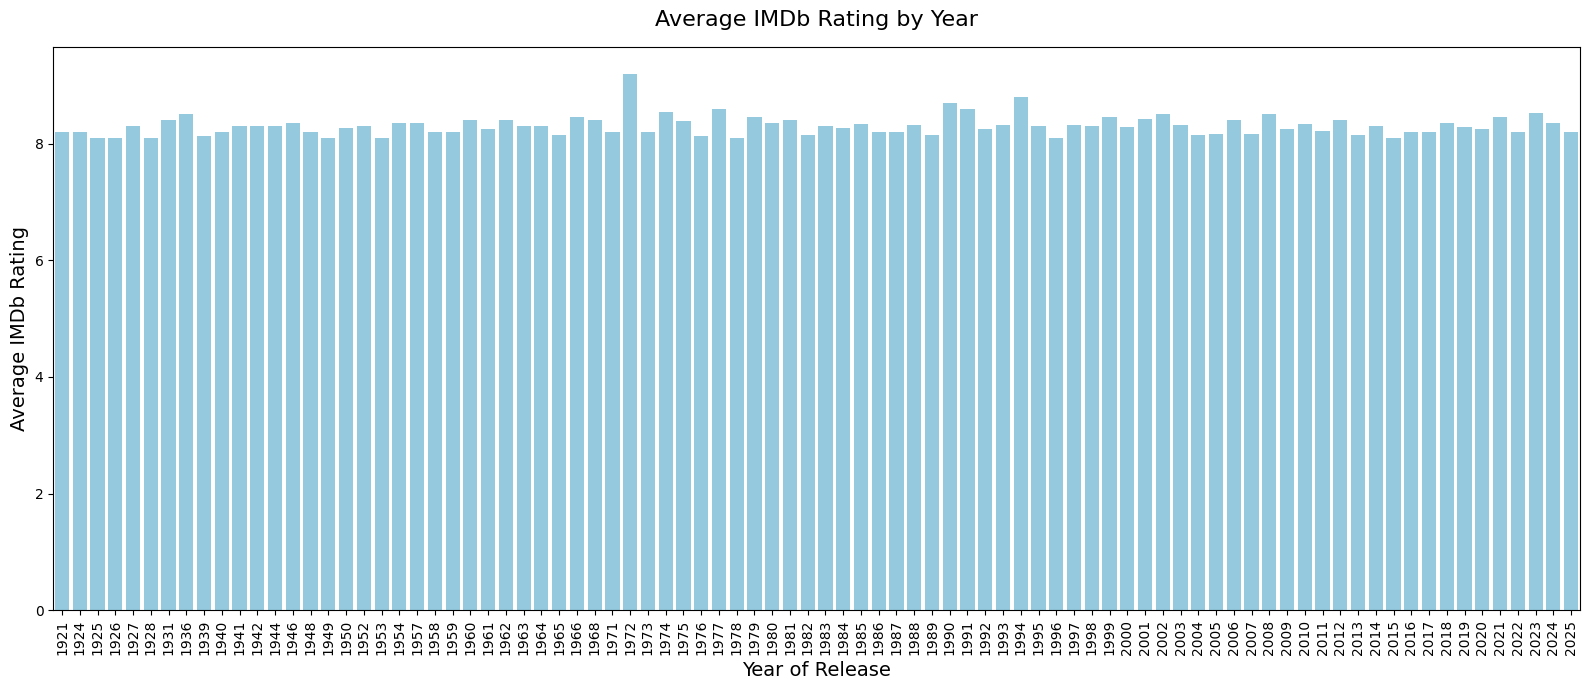

In [34]:
# Drop rows with missing values in 'Year' or 'Rating'
df_year_rating = df.dropna(subset=['Year', 'Rating'])

# Group by year and calculate the average rating
yearly_avg = df_year_rating.groupby('Year')['Rating'].mean().reset_index()

plt.figure(figsize=(16, 7))
sns.barplot(x='Year', y='Rating', data=yearly_avg, color='skyblue')
plt.title('Average IMDb Rating by Year', fontsize=16, pad=15)
plt.xlabel('Year of Release', fontsize=14)
plt.ylabel('Average IMDb Rating', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

5.16 Correlation Matrix Visualization

5.16.1 Correlation Matrix

In [35]:
def plot_correlations(df):
    numeric_df = df[['Year', 'Rating', 'Runtime']].dropna()
    corr_matrix = numeric_df.corr()

    plt.figure(figsize=(10,8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
               center=0, linewidths=.5)
    plt.title('Feature Correlation Matrix', pad=20, fontsize=16)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()

5.16.2 Explode the entire DataFrame on the 'Genres' column

In [36]:
df_exploded = df.explode('Genres')

5.16.3 Create a cross-tabulation of genres and decades

In [37]:
genre_decade_counts = pd.crosstab(df_exploded['Decade'], df_exploded['Genres'])

5.16.4 Create the heatmap

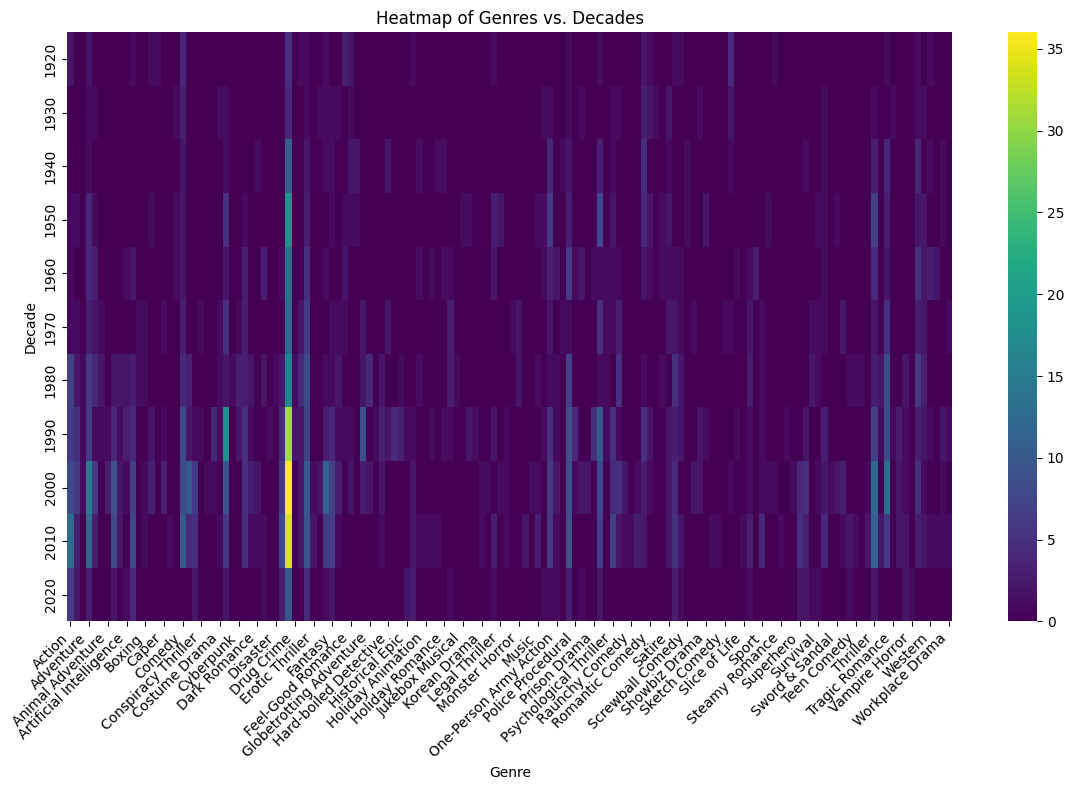

In [38]:
plt.figure(figsize=(12, 8))
sns.heatmap(genre_decade_counts, cmap='viridis', annot=False, fmt='d')
plt.title('Heatmap of Genres vs. Decades')
plt.xlabel('Genre')
plt.ylabel('Decade')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

5.17 Comprehensive Genre Analysis Across Decades

5.17.1 Create exploded genres DataFrame

In [39]:
df_exploded = df.explode('Genres')

5.17.2 Get all unique genres

In [40]:
all_genres = df_exploded['Genres'].unique()

5.17.3 Create decade column

In [41]:
df['Decade'] = (df['Year'] // 10) * 10

5.17.4 Initialize DataFrame

In [42]:
genre_decade = pd.DataFrame(columns=['Genre', 'Decade', 'Count'])

5.17.5 Get unique decades

In [43]:
decades = df['Decade'].dropna().unique()

5.17.6 Populate genre counts per decade

In [44]:
for decade in decades:
    decade_movies = df[df['Decade'] == decade]
    for genre in all_genres:
        count = sum(1 for genres in decade_movies['Genres'] if genre in genres)
        genre_decade = pd.concat([
            genre_decade,
            pd.DataFrame({'Genre': [genre], 'Decade': [decade], 'Count': [count]})
        ], ignore_index=True)

5.17.7 Pivot for better visualization

In [45]:
genre_decade_pivot = genre_decade.pivot(index='Genre', columns='Decade', values='Count').fillna(0)

<ipython-input-45-31ffd32d8f2b>:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  genre_decade_pivot = genre_decade.pivot(index='Genre', columns='Decade', values='Count').fillna(0)


5.17.8 Display top genres

In [46]:
print(genre_decade_pivot.sort_values(by=genre_decade_pivot.columns.tolist(), ascending=False).head(10))


Decade             1920  1930  1940  1950  1960  1970  1980  1990  2000  2010  \
Genre                                                                           
Drama                 5     4    11    18    13    12    16    31    36    34   
Comedy                4     3     2     2     2     3     4     8     8    10   
Slapstick             4     2     1     0     0     1     0     0     1     0   
Farce                 3     0     0     1     2     1     0     1     0     0   
Romance               2     3     5     4     2     0     1     5     3     2   
Feel-Good Romance     2     1     2     1     0     0     0     1     2     0   
Adventure             2     1     1     4     4     3     6     6    15    12   
Action                2     0     0     1     1     1     7     6     8    12   
Romantic Comedy       1     2     0     2     1     0     0     2     1     0   
War                   1     1     4     2     5     3     6     3     5     3   

Decade             2020  
G

5.17.9 Heatmap of Genre Frequency by Decade

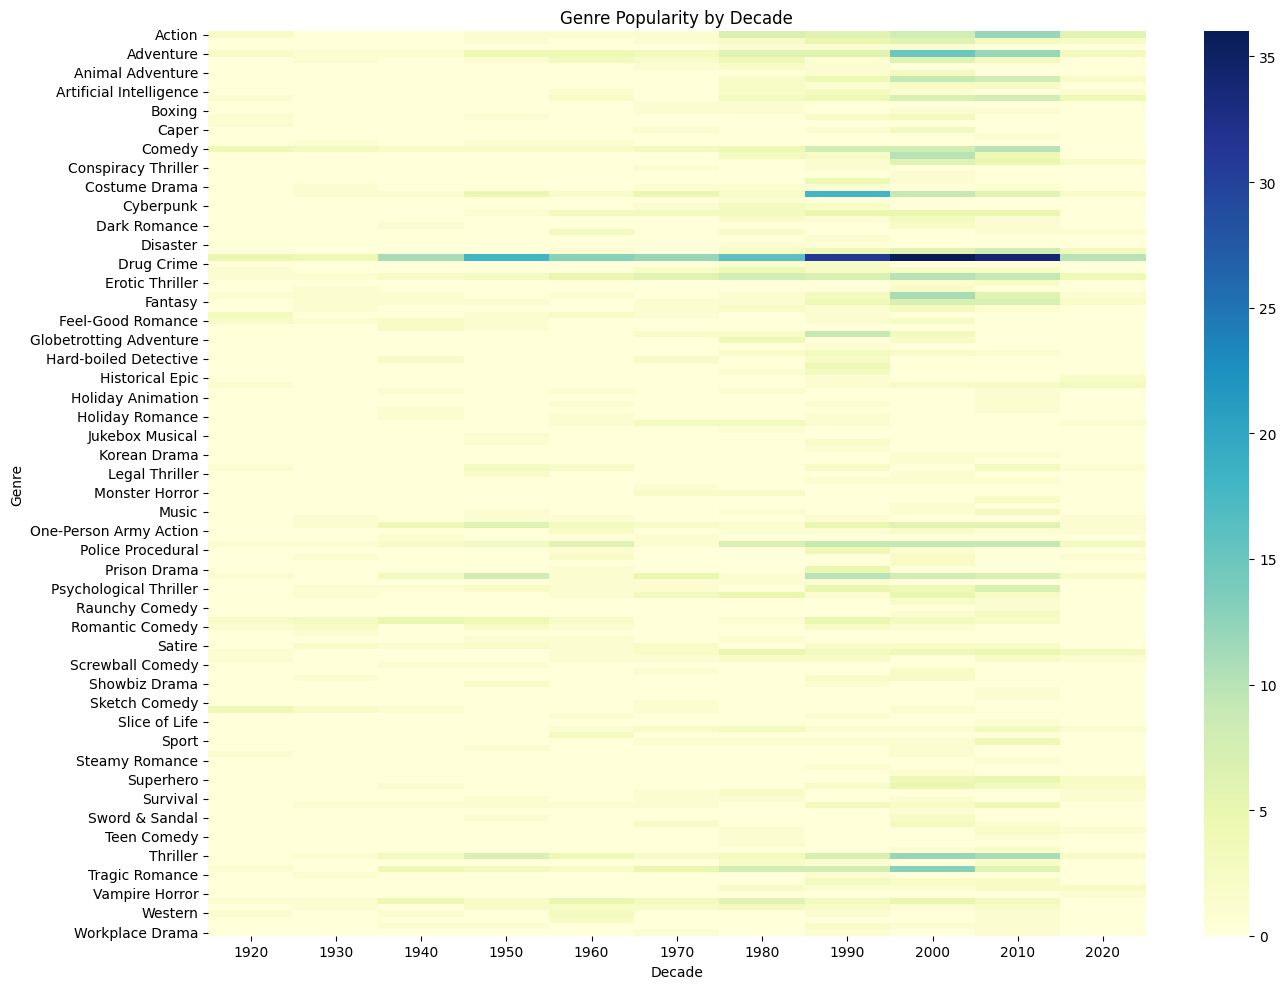

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(genre_decade_pivot, annot=False, cmap='YlGnBu', fmt='g')
plt.title('Genre Popularity by Decade')
plt.ylabel('Genre')
plt.xlabel('Decade')
plt.tight_layout()
plt.show()

5.18 Rating Box Plot Distribution Across Top 15 Movie Genres

<ipython-input-48-97d9fae98d24>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


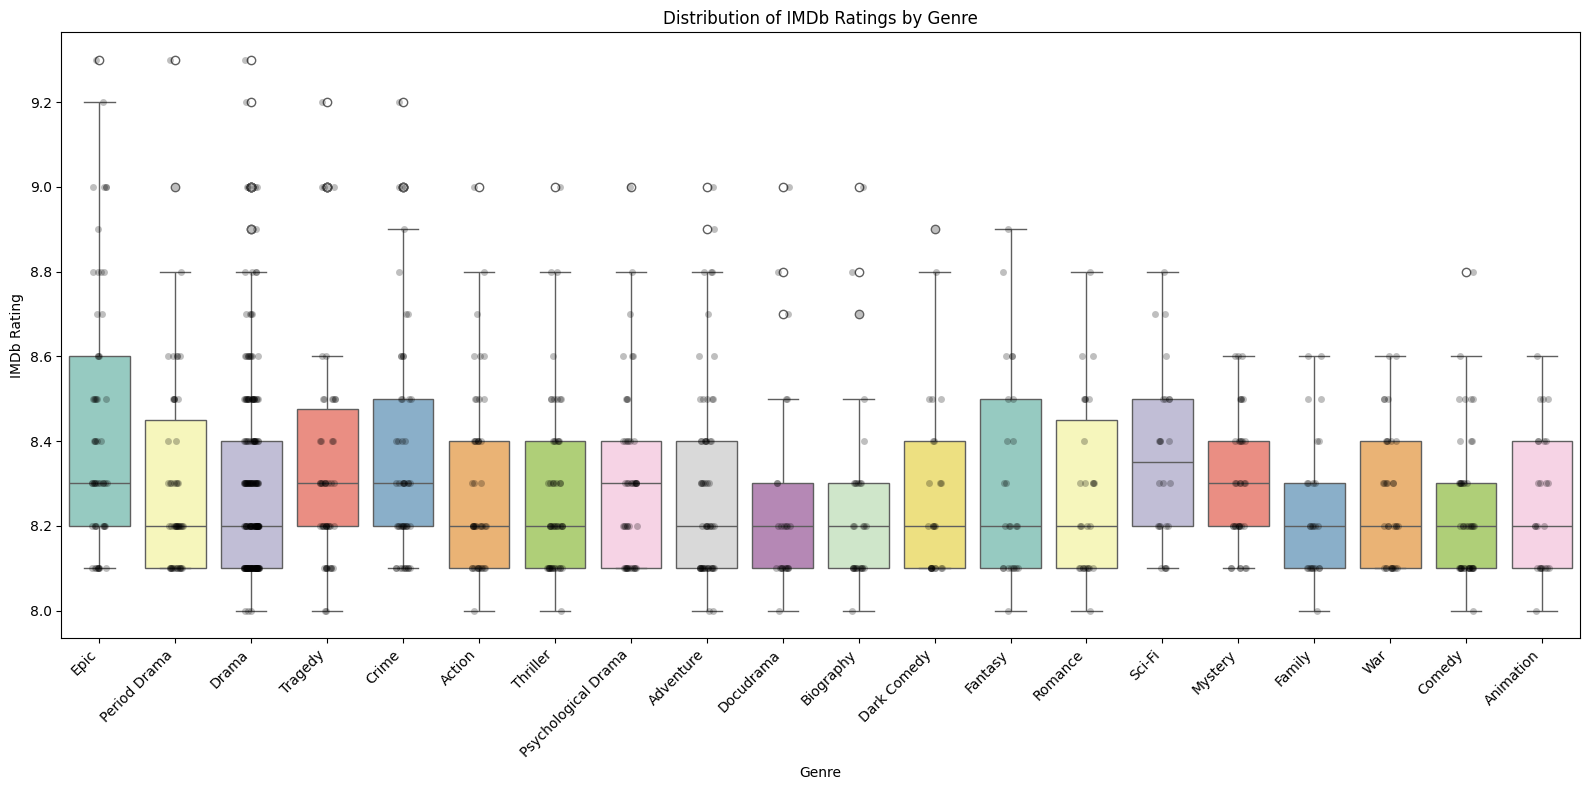

In [48]:
import matplotlib.pyplot as plt
def plot_genre_vs_rating(df_exploded):
    plt.figure(figsize=(16, 8))

    top_genres = df_exploded['Genres'].value_counts().index[:15]
    sns.boxplot(
        data=df_exploded[df_exploded['Genres'].isin(top_genres)],
        x='Genres', y='Rating', palette='Set3'
    )
    sns.stripplot(
        data=df_exploded[df_exploded['Genres'].isin(top_genres)],
        x='Genres', y='Rating', color='black', alpha=0.25, jitter=True
    )
    plt.title('Distribution of IMDb Ratings by Genre')
    plt.xlabel('Genre')
    plt.ylabel('IMDb Rating')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
plot_genre_vs_rating(df_exploded)


5.19 Correlation Between Movie Runtime and IMDb Rating

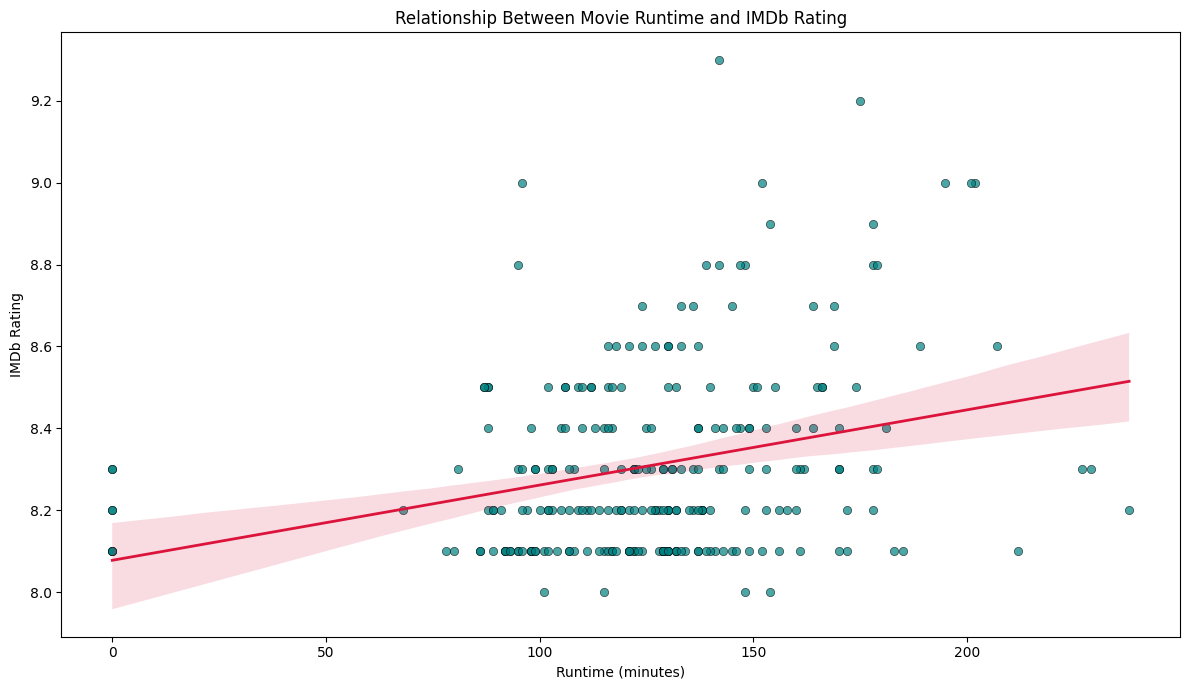

In [49]:
length_parts = df['Length'].str.extract(r'(\d+)h\s*(\d*)m').astype(float).fillna(0)
df['Runtime'] = length_parts[0] * 60 + length_parts[1]

def plot_length_vs_rating(df):
    plt.figure(figsize=(12, 7))
    sns.scatterplot(
        data=df, x='Runtime', y='Rating',
        alpha=0.7, color='teal', edgecolor='k'
    )
    sns.regplot(
        data=df, x='Runtime', y='Rating',
        scatter=False, color='crimson', line_kws={'linewidth':2}
    )
    plt.title('Relationship Between Movie Runtime and IMDb Rating')
    plt.xlabel('Runtime (minutes)')
    plt.ylabel('IMDb Rating')
    plt.tight_layout()
    plt.show()

plot_length_vs_rating(df)


# 6. Linear Regression Analysis

6.1 Importing required libraries

In [56]:
import statsmodels.api as sm

6.2 Linear Regression of impact of Year on IMDb Rating

6.2.1 Getting 'votes' and 'Rating' as Columns

In [57]:
X = df['Year']
y = df['Rating']

6.2.2 Add a constant to the independent variable for the intercept term

In [58]:
X = sm.add_constant(X)

6.2.3 Fit the linear regression model

In [59]:
model = sm.OLS(y, X).fit()

6.2.4 Print the summary of the regression model

In [60]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.3192
Date:                Thu, 01 May 2025   Prob (F-statistic):              0.573
Time:                        05:53:34   Log-Likelihood:                 8.3887
No. Observations:                 250   AIC:                            -12.78
Df Residuals:                     248   BIC:                            -5.734
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.6562      1.157      6.616      0.0

6.3 Linear Regression Analysis: Impact of Vote Count on IMDb Rating

6.3.1 Getting 'Length_Minutes' and 'Rating' as Columns

In [61]:
X = df['Length_Minutes']
y = df['Rating']

6.3.2 Add a constant to the independent variable for the intercept term

In [62]:
X = sm.add_constant(X)

6.3.3 Fit the linear regression model

In [63]:
model = sm.OLS(y, X).fit()

6.3.4 Print the summary of the regression model

In [64]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     21.51
Date:                Thu, 01 May 2025   Prob (F-statistic):           5.71e-06
Time:                        05:58:01   Log-Likelihood:                 18.624
No. Observations:                 250   AIC:                            -33.25
Df Residuals:                     248   BIC:                            -26.20
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              8.0778      0.052    155.

# 7. Predicting Linear Regressions

7.1 Importing Libraries for Linear Regression Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

7.2 Impact of Year on IMDb Rating

7.2.1 Use a subset of year and rating for prediction

In [66]:
df = df.dropna(subset=['Year', 'Rating'])
X = df[['Year']]
y = df['Rating']

7.2.2 Split and train a simple model

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

7.2.3 Predict and compare

In [68]:
X_test = X_test.copy()
X_test['predicted_rating'] = model.predict(X_test)
X_test['actual_rating'] = y_test.values

7.2.4 Display results

In [69]:
X_test.head()

,Year,predicted_rating,actual_rating
142,1995,8.305771,8.2
6,1993,8.305566,9.0
97,1968,8.303006,8.3
60,2018,8.308127,8.4
112,2011,8.307410,8.3


7.3 Impact of Movie Run Time on IMDb Rating

7.3.1 Use a subset of run time and rating for prediction

In [ ]:
df = df.dropna(subset=['Runtime', 'Rating'])
X = df[['Runtime']]
y = df['Rating']

7.3.2 Split and train the model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

7.3.3 Predict and compare

In [ ]:
X_test = X_test.copy()
X_test['predicted_rating'] = model.predict(X_test)
X_test['actual_rating'] = y_test.values

7.3.4 Display results

In [ ]:
X_test.head()